Train a LinearSVC on a linearly separable dataset. Then train an SVC and a
SGDClassifier on the same dataset. See if you can get them to produce roughly
the same model.

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()

iris_data = iris.data
iris_target = iris.target

In [142]:
print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


We will only use two features, which have maximum variance.  
We will only work with two classes, setosa and versicolor

In [143]:
print(np.var(iris.data[:,0]))
print(np.var(iris.data[:,1]))
print(np.var(iris.data[:,2]))
print(np.var(iris.data[:,3]))

0.6811222222222223
0.1887128888888889
3.0955026666666665
0.5771328888888888


In [144]:
indices = (iris_target == 0) | (iris_target == 1)

X = iris_data[indices][:, [2, 3]]
y = iris_target[indices]

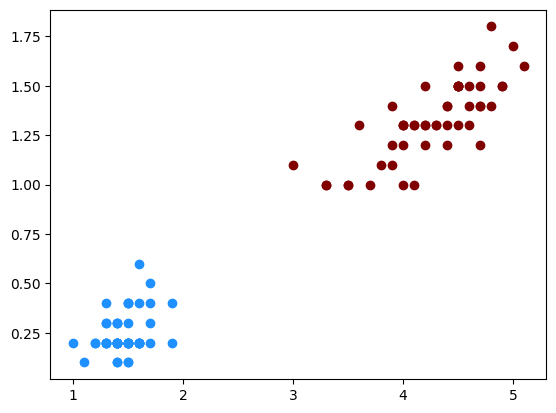

In [145]:
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color="dodgerblue")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color="maroon")

Lets scale

In [146]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() 
X = scaler.fit_transform(X)

Lets work on the model now

In [170]:
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier

C = 1
alpha = 0.1

lin_clf = LinearSVC(loss="hinge", C=C, random_state=42)
svc_clf = SVC(kernel="linear", C=C, random_state=42)
sgd_clf = SGDClassifier(loss="hinge", alpha=alpha, random_state=42)

In [171]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42) 

In [172]:
from sklearn.metrics import accuracy_score

lin_clf.fit(X_train, y_train)
svc_clf.fit(X_train, y_train)
sgd_clf.fit(X_train, y_train)

print("LinearSVC: ", accuracy_score(y_test, lin_clf.predict(X_test)))
print("SVC: ", accuracy_score(y_test, svc_clf.predict(X_test)))
print("SGDClassifier: ", accuracy_score(y_test, sgd_clf.predict(X_test)))

LinearSVC:  1.0
SVC:  1.0
SGDClassifier:  1.0


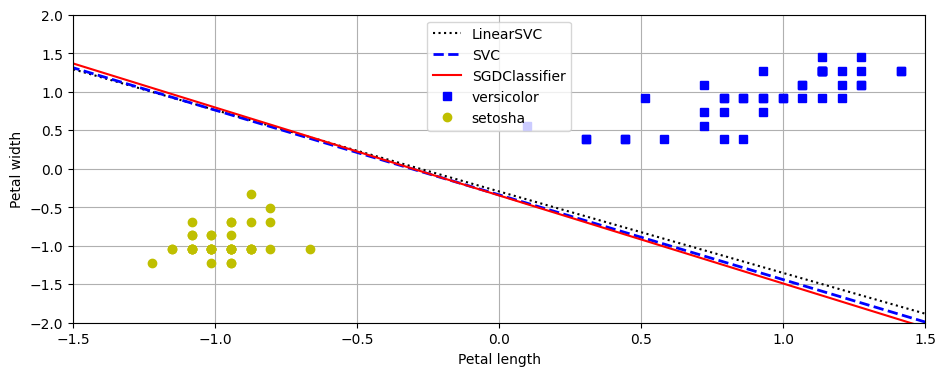

In [173]:
def compute_decision_boundary(model):
    w = -model.coef_[0, 0] / model.coef_[0, 1]
    b = -model.intercept_[0] / model.coef_[0, 1]
    return np.array([[-10, -10 * w + b], [10, 10 * w + b]])

lin_line = compute_decision_boundary(lin_clf)
svc_line = compute_decision_boundary(svc_clf)
sgd_line = compute_decision_boundary(sgd_clf)

# Plot all three decision boundaries
plt.figure(figsize=(11, 4))
plt.plot(lin_line[:, 0], lin_line[:, 1], "k:", label="LinearSVC")
plt.plot(svc_line[:, 0], svc_line[:, 1], "b--", linewidth=2, label="SVC")
plt.plot(sgd_line[:, 0], sgd_line[:, 1], "r-", label="SGDClassifier")
plt.plot(X_train[:, 0][y_train==1], X_train[:, 1][y_train==1], "bs", label="versicolor") 
plt.plot(X_train[:, 0][y_train==0], X_train[:, 1][y_train==0], "yo", label="setosha") 
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper center")
plt.axis([-1.5, 1.5, -2, 2])
plt.grid()

plt.show()